# Heart Disease Prediction Using Machine Learning

## Week 4 Task: Machine Learning Model Development and Evaluation

### Objective:
The objective of this project is to develop a machine learning classification model that predicts the presence of heart disease based on patient medical attributes.

The complete machine learning pipeline includes:
- Data loading
- Data exploration
- Data preprocessing
- Feature scaling
- Model training
- Performance evaluation
- Visualization
- Error analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cleaned_merged_heart_dataset.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape

(1888, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.135593,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.103852,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The dataset does not contain missing values. Therefore, no missing value treatment is required.

In [7]:
df.duplicated().sum()

np.int64(1286)

In [8]:
df.drop_duplicates(inplace=True)

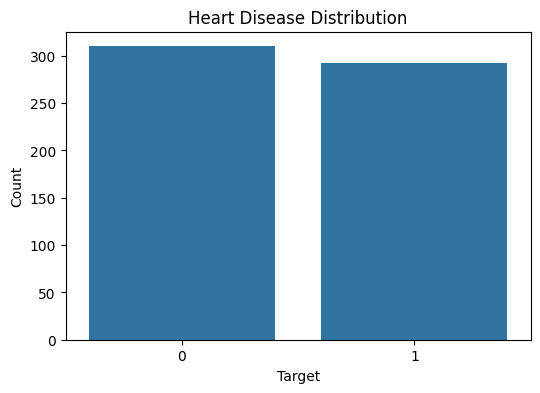

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

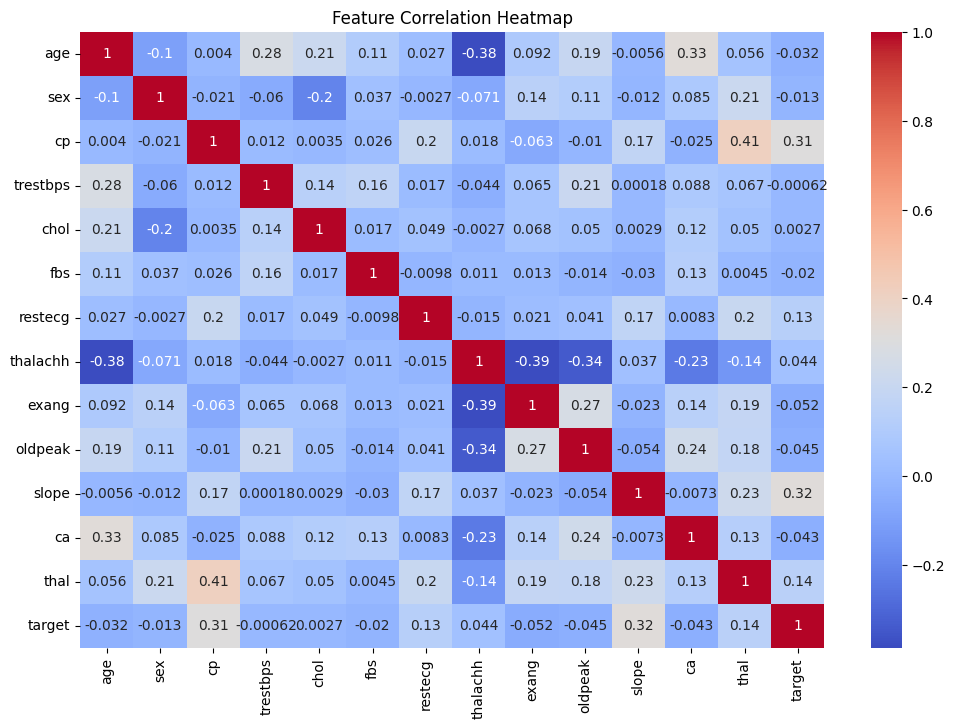

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
X = df.drop("target", axis=1)

y = df["target"]

In [12]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

80% of the data is used for training and 20% is used for testing the model performance.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [16]:
lr_prediction = lr_model.predict(
    X_test_scaled
)

lr_probability = lr_model.predict_proba(
    X_test_scaled
)[:,1]

In [17]:
lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)

lr_precision = precision_score(
    y_test,
    lr_prediction
)

lr_recall = recall_score(
    y_test,
    lr_prediction
)

lr_f1 = f1_score(
    y_test,
    lr_prediction
)


print("Accuracy:",lr_accuracy)
print("Precision:",lr_precision)
print("Recall:",lr_recall)
print("F1 Score:",lr_f1)

Accuracy: 0.6942148760330579
Precision: 0.7017543859649122
Recall: 0.6666666666666666
F1 Score: 0.6837606837606838


In [18]:
print(
    classification_report(
        y_test,
        lr_prediction
    )
)

              precision    recall  f1-score   support

           0       0.69      0.72      0.70        61
           1       0.70      0.67      0.68        60

    accuracy                           0.69       121
   macro avg       0.69      0.69      0.69       121
weighted avg       0.69      0.69      0.69       121



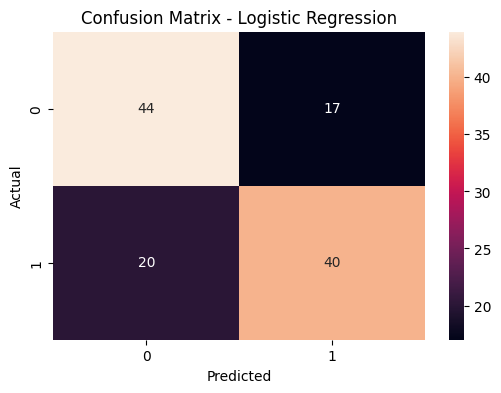

In [19]:
cm = confusion_matrix(
    y_test,
    lr_prediction
)


plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.show()

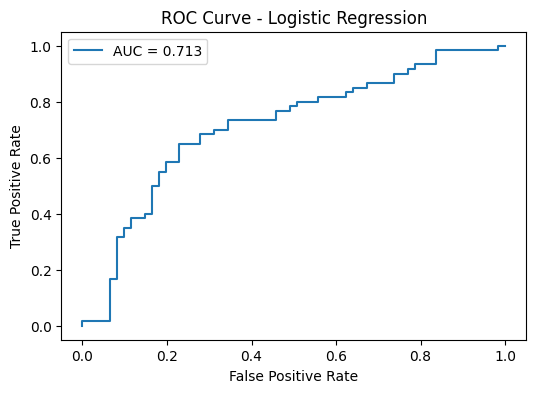

In [20]:
fpr,tpr,threshold = roc_curve(
    y_test,
    lr_probability
)


auc_score = roc_auc_score(
    y_test,
    lr_probability
)


plt.figure(figsize=(6,4))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Logistic Regression"
)


plt.legend()

plt.show()

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [22]:
rf_prediction = rf_model.predict(
    X_test
)

rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

In [23]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


rf_precision = precision_score(
    y_test,
    rf_prediction
)


rf_recall = recall_score(
    y_test,
    rf_prediction
)


rf_f1 = f1_score(
    y_test,
    rf_prediction
)


print("Accuracy:",rf_accuracy)
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)

Accuracy: 0.7603305785123967
Precision: 0.746031746031746
Recall: 0.7833333333333333
F1 Score: 0.7642276422764228


In [24]:
results = pd.DataFrame({

"Model":[
    "Logistic Regression",
    "Random Forest"
],

"Accuracy":[
    lr_accuracy,
    rf_accuracy
],

"Precision":[
    lr_precision,
    rf_precision
],

"Recall":[
    lr_recall,
    rf_recall
],

"F1 Score":[
    lr_f1,
    rf_f1
]

})


results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.694215,0.701754,0.666667,0.683761
1,Random Forest,0.760331,0.746032,0.783333,0.764228


In [25]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":
rf_model.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
12,thal,0.192172
2,cp,0.100313
10,slope,0.098477
7,thalachh,0.097609
4,chol,0.094926
0,age,0.084081
9,oldpeak,0.082365
3,trestbps,0.078669
11,ca,0.061548
6,restecg,0.046726


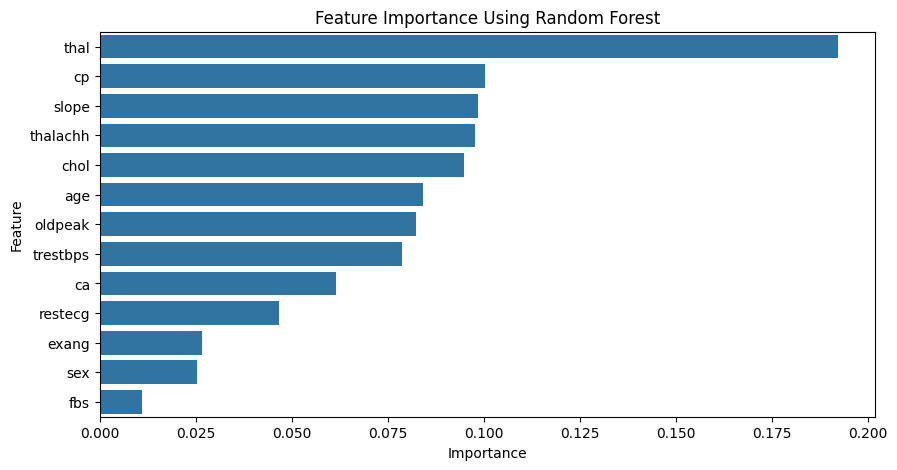

In [26]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=importance.sort_values(
        by="Importance",
        ascending=False
    ),
    x="Importance",
    y="Feature"
)


plt.title(
    "Feature Importance Using Random Forest"
)


plt.show()

# Conclusion

In this project, a machine learning classification system was developed for predicting heart disease using patient medical attributes.

The dataset was cleaned and analyzed before applying machine learning algorithms. Feature scaling was performed to improve model performance.

Two classification algorithms were implemented:

1. Logistic Regression
2. Random Forest Classifier

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve

The results show that machine learning algorithms can effectively identify patterns related to heart disease prediction.

## Limitations:
- Dataset size is limited.
- Medical prediction requires more diverse patient data.
- Some important lifestyle factors may not be included.

## Future Improvements:
- Hyperparameter tuning
- Cross-validation
- XGBoost implementation
- Neural Network models
- Larger medical datasets